In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
df = pd.read_csv('titanic.csv')

In [48]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [49]:
df["Cabin"] = df["Cabin"].fillna("Unknown")

group_median_age = df.groupby(["Sex", "Pclass"])["Age"].transform("median")
df["Age"] = df["Age"].fillna(group_median_age)

df.dropna(inplace = True)

In [50]:
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [51]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S


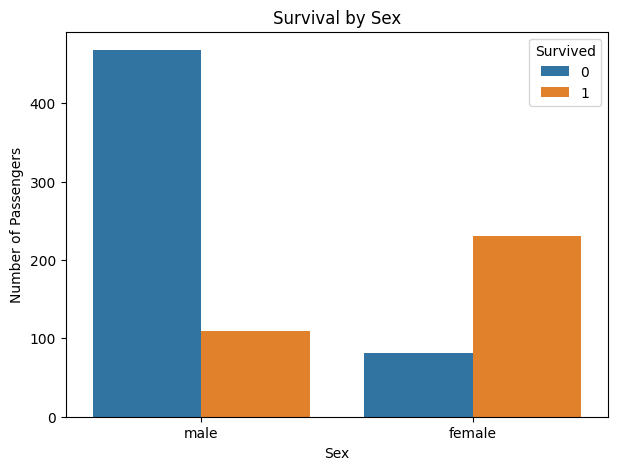

In [66]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="Sex", hue="Survived")
plt.title("Survival by Sex")
plt.xlabel("Sex")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived")
plt.show()

### Insight: Survival by Sex
1. Female passengers show a much higher survival count than male passengers.
2. Male passengers form the majority of non-survivors in this dataset.
3. Sex appears to be a strong predictor of survival outcome on the Titanic.

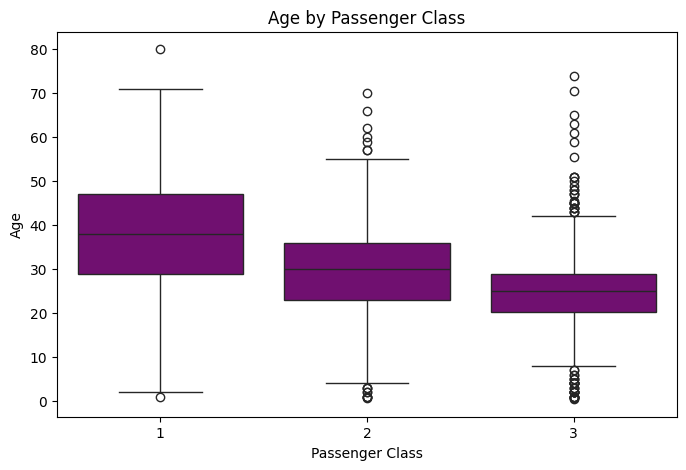

In [64]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Pclass", y="Age", color="purple")
plt.title("Age by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Age")
plt.show()

### Insight: Age by Passenger Class
1. Passengers in 1st class tend to be older on average than those in lower classes.
2. 3rd class shows a younger and wider spread of ages, including many children.
3. The spread and outliers suggest age composition differed substantially by class.

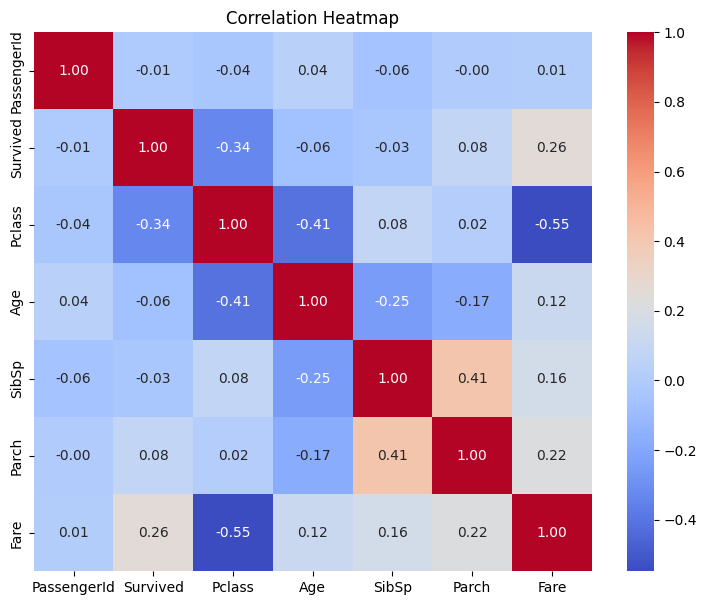

In [58]:
num_df = df.select_dtypes(include="number")

plt.figure(figsize=(9,7))
sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Insight: Correlation Heatmap
1. Survival is moderately associated with class and fare, indicating socioeconomic effects on survival.
2. Pclass and Fare show a strong inverse relationship, as higher classes generally paid more.
3. Age has a weak direct linear relationship with survival in this cleaned dataset, while family-size features (SibSp and Parch) are positively related.